## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [1]:
# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.
from torchvision.datasets import GTSRB

# Your code here.

# Global device variable. Probably a bad idea...
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Your code here.
transform = T.Compose([T.ToTensor()])
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test  = GTSRB('_data/', split='test', transform=transform, download=True)

/home/eros/DLA_Projects/.venv/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [2]:
ds_train[0][0].shape

torch.Size([3, 30, 29])

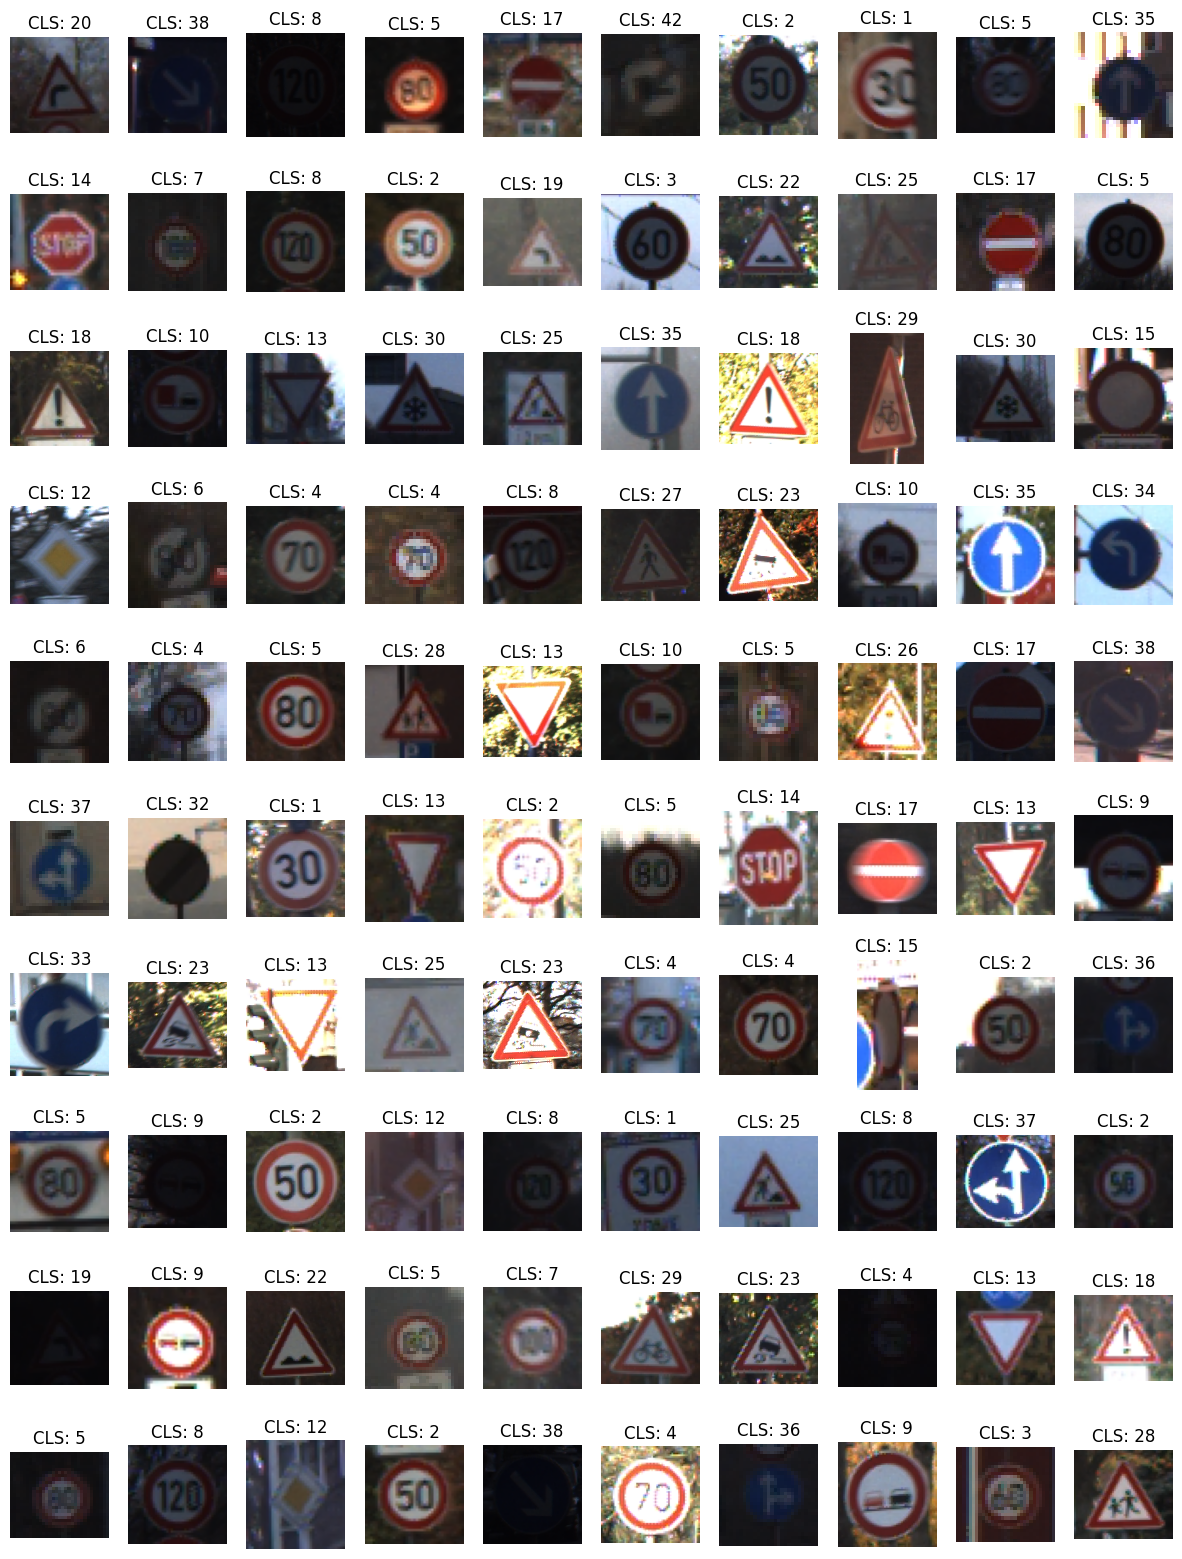

In [3]:
num_samples = 100
image_samples = [ds_train[idx] for idx in np.random.choice(range(len(ds_train)), num_samples)]

plt.figure(figsize=(15,20))
for (idx, (im, cls)) in enumerate(image_samples):
    plt.subplot(10, 10, idx+1)
    plt.imshow(im.permute([1, 2, 0]))
    plt.title(f'CLS: {cls}')
    plt.axis('off')

In [4]:
# Collect metadata statistics in a Pandas dataframe.
import pandas as pd
df_stats = pd.DataFrame([(cls, im.shape[1], im.shape[2]) for (im, cls) in ds_train], columns=['CLS', 'HEIGHT', 'WIDTH'])
df_stats['AR'] = df_stats['WIDTH'] / df_stats['HEIGHT']

In [5]:
df_stats.describe()

,CLS,HEIGHT,WIDTH,AR
count,26640.000000,26640.000000,26640.000000,26640.000000
mean,15.887387,50.365128,50.933784,1.008718
std,12.044099,23.161523,24.373418,0.072100
min,0.000000,25.000000,25.000000,0.368132
25%,5.000000,35.000000,35.000000,0.972222
50%,12.000000,43.000000,43.000000,1.000000
75%,25.000000,58.000000,58.000000,1.044444
max,42.000000,225.000000,243.000000,1.417808


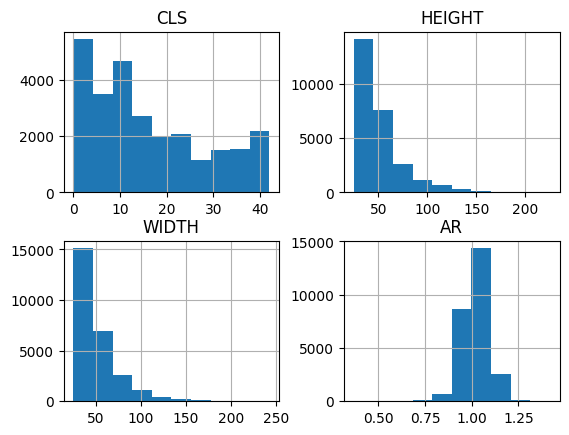

In [6]:
_ = df_stats.hist()

In [7]:
# The "final" transform.
# We use the standard normalization statistics from the torchvision implementation of ResNet.
transform = T.Compose([T.Resize(70), T.RandomCrop((64, 64)), T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test  = GTSRB('_data/', split='test', transform=transform, download=True)

/home/eros/DLA_Projects/.venv/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..2.0822659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..1.7511113].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5527872..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7069099..2.3088455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466565..2.64].
Clipp

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3815396..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..1.5768193].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..0.19991292].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..0.51363856].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870366..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5455182..-0.04

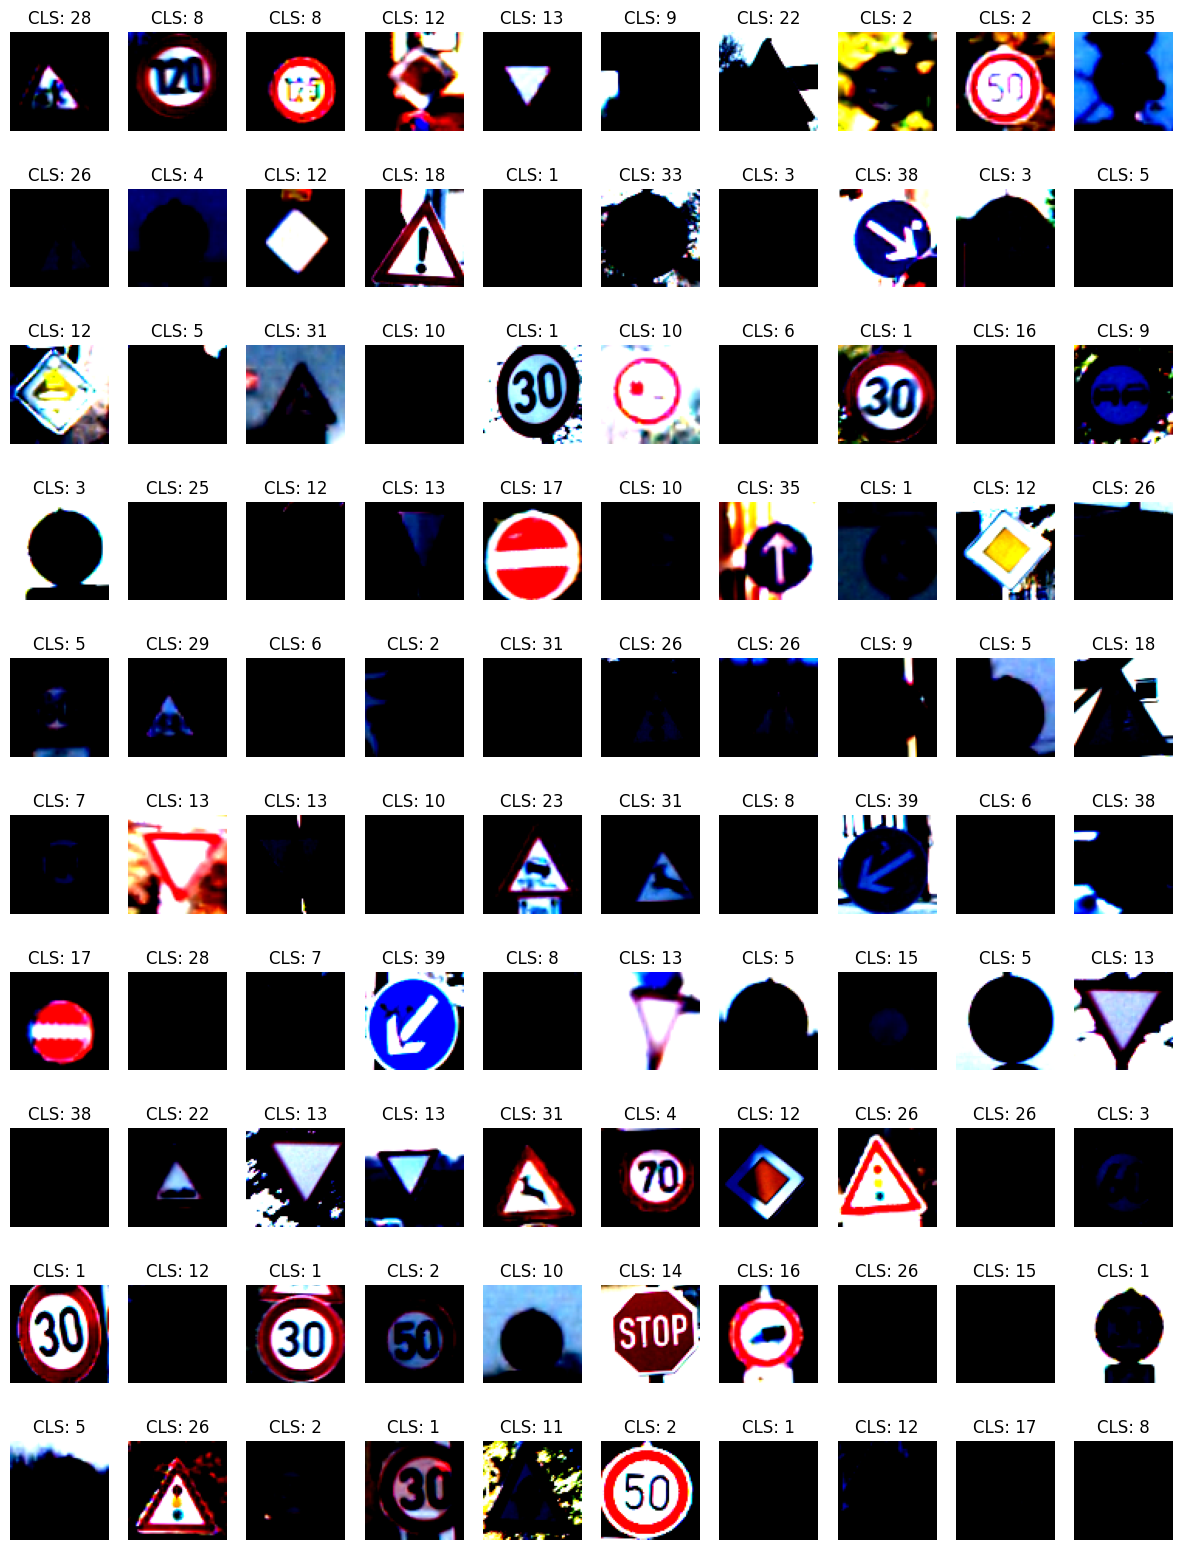

In [8]:
num_samples = 100
image_samples = [ds_train[idx] for idx in np.random.choice(range(len(ds_train)), num_samples)]

plt.figure(figsize=(15,20))
for (idx, (im, cls)) in enumerate(image_samples):
    plt.subplot(10, 10, idx+1)
    plt.imshow(im.permute([1, 2, 0]))
    plt.title(f'CLS: {cls}')
    plt.axis('off')

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [9]:
from torchvision.models import list_models, get_model

In [10]:
list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [11]:
len(ds_test), len(ds_train)

(12630, 26640)

In [12]:
# Your code here.
from torch.utils.data import DataLoader
import torch.nn as nn

# The training dataloader.
batch_size = 1024
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, )
dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=True)

# Load our ResNet model.
model = get_model('resnet18', weights='DEFAULT')
model.fc = nn.Identity()  # Replace classifier with identity to extract features.
model = model.to(device)

In [13]:
from tqdm.notebook import tqdm

train_feats = []
train_classes = []
model.eval()
for (ims, cls) in tqdm(dl_train):
    ims = ims.to(device)
    with torch.no_grad():
        train_feats.append(model(ims))
    train_classes.append(cls)
train_feats = torch.vstack(train_feats).cpu()
train_classes = torch.concat(train_classes)

  0%|          | 0/27 [00:00<?, ?it/s]

In [14]:
train_feats.shape

torch.Size([26640, 512])

In [15]:
test_feats = []
test_classes = []
model.eval()
for (ims, cls) in tqdm(dl_test):
    ims = ims.to(device)
    with torch.no_grad():
        test_feats.append(model(ims))
    test_classes.append(cls)
test_feats = torch.vstack(test_feats).cpu()
test_classes = torch.concat(test_classes)

  0%|          | 0/13 [00:00<?, ?it/s]

In [16]:
# A reproducible baseline.
from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(train_feats, train_classes)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
from sklearn.metrics import classification_report

print(classification_report(svc.predict(test_feats), test_classes))

              precision    recall  f1-score   support

           0       0.30      0.24      0.27        74
           1       0.65      0.51      0.57       925
           2       0.46      0.40      0.43       857
           3       0.36      0.33      0.34       489
           4       0.54      0.63      0.58       566
           5       0.44      0.50      0.47       554
           6       0.79      0.95      0.87       125
           7       0.52      0.55      0.53       423
           8       0.36      0.41      0.38       390
           9       0.78      0.86      0.82       434
          10       0.87      0.84      0.85       685
          11       0.64      0.47      0.54       565
          12       0.97      0.93      0.95       722
          13       0.99      0.95      0.97       750
          14       0.83      0.95      0.89       238
          15       0.96      0.96      0.96       210
          16       0.79      0.87      0.83       135
          17       0.84    


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

In [18]:
# Simple training code from FML...
from sklearn.metrics import accuracy_score
import torch.nn.functional as F

# Function to train a model for a single epoch over the data loader.
def train_epoch(model, dl, opt, epoch='Unknown', device='cpu'):
    model.train()
    losses = []
    for (xs, ys) in tqdm(dl, desc=f'Training epoch {epoch}', leave=True):
        xs = xs.to(device)
        ys = ys.to(device)
        opt.zero_grad()
        logits = model(xs)
        loss = F.cross_entropy(logits, ys)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return np.mean(losses)

# Function to evaluate model over all samples in the data loader.
def evaluate_model(model, dl, device='cpu'):
    model.eval()
    predictions = []
    gts = []
    for (xs, ys) in tqdm(dl, desc='Evaluating', leave=False):
        xs = xs.to(device)
        preds = torch.argmax(model(xs), dim=1)
        gts.append(ys)
        predictions.append(preds.detach().cpu().numpy())
        
    # Return accuracy score and classification report.
    return (accuracy_score(np.hstack(gts), np.hstack(predictions)),
            classification_report(np.hstack(gts), np.hstack(predictions), zero_division=0, digits=3))

# Simple function to count the parameters in a model.
def count_parameters(model):
    return np.sum([p.numel() for p in model.parameters()])

In [19]:
# Your code here.

# Load our ResNet model.
model = get_model('resnet18', weights='DEFAULT')
model.fc = nn.Linear(512, 43)  # Replace classifier with identity to extract features.
model = model.to(device)

# The training dataloader.
batch_size = 1024
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=True)

  0%|          | 0/30 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 5:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 6:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 7:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 8:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 9:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 10:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 11:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 12:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 13:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 14:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 15:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 16:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 17:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 18:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 19:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 20:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 21:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 22:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 23:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 24:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 25:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 26:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 27:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 28:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 29:   0%|          | 0/27 [00:00<?, ?it/s]

Training epoch 30:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0      0.833     0.917     0.873        60
           1      0.946     0.957     0.952       720
           2      0.923     0.972     0.947       750
           3      0.963     0.931     0.947       450
           4      0.984     0.947     0.965       660
           5      0.906     0.905     0.905       630
           6      0.993     0.960     0.976       150
           7      0.964     0.964     0.964       450
           8      0.930     0.913     0.922       450
           9      0.968     0.998     0.983       480
          10      1.000     0.998     0.999       660
          11      0.956     0.940     0.948       420
          12      0.999     0.997     0.998       690
          13      0.985     1.000     0.992       720
          14      0.950     0.907     0.928       270
          15      0.981     0.990     0.986       210
          16      1.000     1.000     1.000       150
          17      0.988    

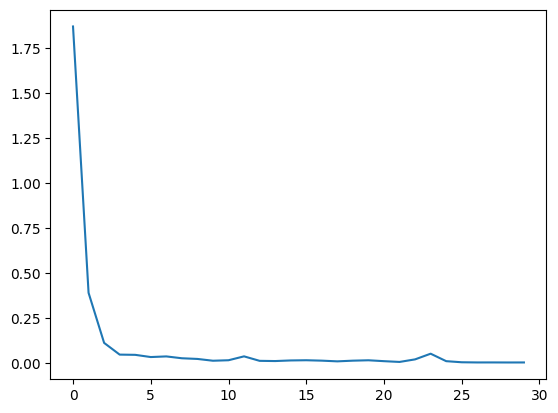

In [20]:
epochs = 30
lr = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

losses = []
for epoch in tqdm(range(epochs)):
    losses.append(train_epoch(model, dl_train, optimizer, epoch+1, device=device))

plt.plot(losses)
(accuracy, cls_report) = evaluate_model(model, dl_test, device=device)
print(cls_report)

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

### Sezione import

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB
import pandas as pd
from torchvision.models import list_models, get_model
from torch.utils.data import DataLoader, random_split
from tqdm.notebook import tqdm
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import wandb

### Configurazione variabili

In [30]:
config = {
    # Dataset
    "data_dir":    "_data/",
    "img_size":    70,
    "crop_size":   64,
    "num_classes": 43,

    # DataLoader
    "batch_size":  1024,
    "num_workers": 4,
    "val_split": 0.2,

    # Modello
    "model_name":  "resnet18",   # qualsiasi nome valido per torchvision get_model
    "pretrained":  True,

    # Training
    "epochs":      30,
    "optimizer":   "adam",       # "adam" | "sgd"
    "lr":          1e-4,
    "weight_decay": 0.0,

    # WandB
    "project":     "DLA-Lab1",
    "run_name":    "resnet18-baseline",
}

### Builders

In [31]:
def build_transforms(img_size: int, crop_size: int, augment: bool = False):
    # Trasformazioni per train e test.
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if augment:
        train_tf = T.Compose([
            T.Resize(img_size),
            T.RandomCrop((crop_size, crop_size)),
            T.RandomHorizontalFlip(),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])
    else:
        train_tf = T.Compose([
            T.Resize(img_size),
            T.RandomCrop((crop_size, crop_size)),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])

    test_tf = T.Compose([
        T.Resize(img_size),
        T.CenterCrop((crop_size, crop_size)),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ])

    return train_tf, test_tf


def build_dataloaders(cfg: dict):
    train_tf, test_tf = build_transforms(cfg["img_size"], cfg["crop_size"])

    ds_train_full = GTSRB(cfg["data_dir"], split="train", transform=train_tf, download=True)
    ds_test       = GTSRB(cfg["data_dir"], split="test",  transform=test_tf,  download=True)

    # Ricava la validation dal training set (es. 80/20)
    val_size   = int(len(ds_train_full) * cfg["val_split"])
    train_size = len(ds_train_full) - val_size
    ds_train, ds_val = random_split(ds_train_full, [train_size, val_size])

    dl_train = DataLoader(ds_train, batch_size=cfg["batch_size"], shuffle=True,  num_workers=cfg["num_workers"], pin_memory=True)
    dl_val   = DataLoader(ds_val,   batch_size=cfg["batch_size"], shuffle=False, num_workers=cfg["num_workers"], pin_memory=True)
    dl_test  = DataLoader(ds_test,  batch_size=cfg["batch_size"], shuffle=False, num_workers=cfg["num_workers"], pin_memory=True)

    return dl_train, dl_val, dl_test


def build_model(cfg: dict, device: str):
    # Carica il modello da torchvision e sostituisce il classificatore finale.
    weights = "DEFAULT" if cfg["pretrained"] else None
    model = get_model(cfg["model_name"], weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, cfg["num_classes"])

    return model.to(device)


def build_optimizer(model: nn.Module, cfg: dict):
    # Costruisce l'optimizer in base alla configurazione.
    params = model.parameters()

    if cfg["optimizer"].lower() == "adam":
        return torch.optim.Adam(params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    elif cfg["optimizer"].lower() == "sgd":
        return torch.optim.SGD(params, lr=cfg["lr"], momentum=0.9,
                               weight_decay=cfg["weight_decay"])
    else:
        raise ValueError(f"Optimizer non supportato: {cfg['optimizer']}")

### Training e valutazione

In [32]:
def train_epoch(model, dl, optimizer, device, epoch_idx):
    # Allena il modello per una singola epoca. Restituisce la loss media.
    model.train()
    losses = []
    for (xs, ys) in tqdm(dl, desc=f"Epoch {epoch_idx}", leave=False):
        xs, ys = xs.to(device), ys.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(xs), ys)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


def evaluate_model(model, dl, device):
    # Valuta il modello su un DataLoader. Restituisce accuracy e report.
    model.eval()
    all_preds, all_gts = [], []
    with torch.no_grad():
        for (xs, ys) in tqdm(dl, desc="Evaluating", leave=False):
            preds = torch.argmax(model(xs.to(device)), dim=1).cpu().numpy()
            all_preds.append(preds)
            all_gts.append(ys.numpy())

    all_preds = np.hstack(all_preds)
    all_gts   = np.hstack(all_gts)
    acc    = accuracy_score(all_gts, all_preds)
    report = classification_report(all_gts, all_preds, zero_division=0, digits=3)
    return acc, report

### Pipeline

In [33]:
def run(cfg: dict):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # --- Inizializza WandB ---
    wandb.init(
        project=cfg["project"],
        name=cfg["run_name"],
        config=cfg,        # salva tutti gli iperparametri automaticamente
    )

    # --- Costruisci componenti ---
    dl_train, dl_val, dl_test = build_dataloaders(cfg)
    model             = build_model(cfg, device)
    optimizer         = build_optimizer(model, cfg)

    print(f"Parametri del modello: {sum(p.numel() for p in model.parameters()):,}")

    # --- Training loop ---
    train_losses = []
    val_accuracies = []
    
    for epoch in tqdm(range(1, cfg["epochs"] + 1), desc="Training"):
        loss = train_epoch(model, dl_train, optimizer, device, epoch)
        train_losses.append(loss)

        acc, _ = evaluate_model(model, dl_val, device)  # ← 
        val_accuracies.append(acc)
        
        # Log della loss e dell'accuracy su WandB ad ogni epoca
        wandb.log({"train/loss": loss, "val/accuracy": acc,"epoch": epoch})
                
    # --- Valutazione finale ---
    acc, report = evaluate_model(model, dl_test, device)
    print(f"\nTest Accuracy: {acc:.4f}")
    print(report)

    # Log delle metriche finali su WandB
    wandb.log({"test/accuracy": acc})

    # --- Salva il plot della loss e dell'accuracy ---
    epochs = range(1, cfg["epochs"] + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(epochs, train_losses)
    ax1.set_xlabel("Epoca")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"Training Loss — {cfg['run_name']}")
    
    ax2.plot(epochs, val_accuracies)
    ax2.set_xlabel("Epoca")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"Validation Accuracy — {cfg['run_name']}")
    
    wandb.log({"charts": wandb.Image(fig)})
    plt.show()

    wandb.finish()
    return model

### Run

Device: cuda


Parametri del modello: 11,198,571


/home/eros/DLA_Projects/.venv/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Training:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 5:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 6:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 7:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 8:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 9:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 10:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 11:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 12:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 13:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 14:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 15:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 16:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 17:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 18:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 19:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 20:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 21:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 22:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 23:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 24:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 25:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 26:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 27:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 28:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 29:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 30:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]


Test Accuracy: 0.9549
              precision    recall  f1-score   support

           0      0.836     0.767     0.800        60
           1      0.969     0.958     0.964       720
           2      0.925     0.976     0.950       750
           3      0.952     0.927     0.939       450
           4      0.985     0.964     0.974       660
           5      0.935     0.921     0.928       630
           6      0.968     1.000     0.984       150
           7      0.928     0.980     0.954       450
           8      0.888     0.933     0.910       450
           9      0.996     0.952     0.973       480
          10      0.987     0.998     0.992       660
          11      0.907     0.976     0.940       420
          12      0.997     0.997     0.997       690
          13      0.999     0.994     0.997       720
          14      0.988     0.900     0.942       270
          15      0.995     0.995     0.995       210
          16      1.000     0.967     0.983       150
    

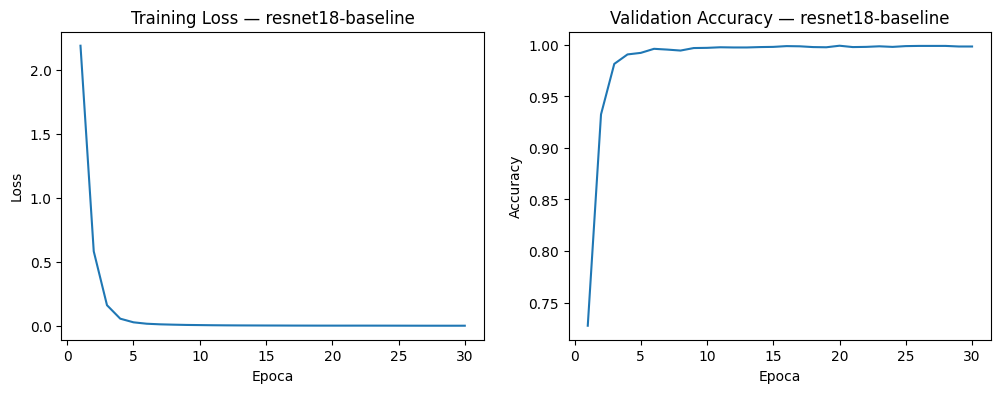

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test/accuracy,▁
train/loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▆████████████████████████████
epoch,30
test/accuracy,0.95495
train/loss,0.00079
val/accuracy,0.9985


In [34]:
model = run(config)


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [27]:
# Your code here.


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [28]:
from datasets import load_dataset

# Download the full detection dataset from the Hugging Face Hub.
# You will want to spend some time studying the organization of this dataset.
ds = load_dataset("keremberke/german-traffic-sign-detection", name="full")

# Your code here.

ModuleNotFoundError: No module named 'datasets'

---
---